<a href="https://colab.research.google.com/github/parthasarathipanda2006/Projects/blob/main/Variational%20Auto%20Encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import tensorflow as tf
from tensorflow import keras
from keras.models  import Sequential
from tensorflow.keras import layers
from tqdm import tqdm

# Load Dataset

In [68]:
(x_train_full, y_train_full), _ = keras.datasets.mnist.load_data()
x_train_processed = (x_train_full.reshape(-1, 28, 28, 1).astype('float32'))/255
BUFFER_SIZE=60000
BATCH_SIZE=128
dataset = tf.data.Dataset.from_tensor_slices(x_train_processed).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# Encoder

In [69]:
def Encoder():
  input=keras.Input(shape=(28,28,1))
  x=layers.Conv2D(64,kernel_size=3,strides=2,padding='same')(input)
  x=layers.BatchNormalization()(x)
  x=keras.activations.relu(x)
  x=layers.MaxPool2D(pool_size=2)(x)
  x=layers.Conv2D(32,kernel_size=3,strides=2,padding='same')(x)
  x=layers.BatchNormalization()(x)
  x=keras.activations.relu(x)
  x=layers.MaxPool2D(pool_size=2)(x)
  x=layers.Flatten()(x)

  z_mean1=layers.Dense(10,activation=None)(x)
  z_mean=layers.Dense(10,name='z_mean',activation=None)(z_mean1)

  z_log_var1=layers.Dense(10,activation=None)(x)
  z_log_var=layers.Dense(10,activation=None,name='z_log_var')(z_log_var1)

  model=keras.Model(inputs=input,outputs=[z_mean,z_log_var])

  return model

In [70]:
Encoder=Encoder()
Encoder.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 14, 14,    │        640 │ input_layer_12[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_30 (ReLU)     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 7, 7, 64)  │          0 │ re_lu_30[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 4, 4, 32)  │     18,464 │ max_pooling2d_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 4, 32)  │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_31 (ReLU)     │ (None, 4, 4, 32)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 2, 2, 32)  │          0 │ re_lu_31[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 128)       │          0 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 10)        │      1,290 │ flatten_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 10)        │      1,290 │ flatten_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 10)        │        110 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 10)        │        110 │ dense_19[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,288 (87.06 KB)

 Trainable params: 22,096 (86.31 KB)

 Non-trainable params: 192 (768.00 B)

# Reparameterization

In [71]:
def Reparameterization(z_mean,z_log_var):
  z=z_mean+tf.exp(0.5*z_log_var)*tf.random.normal(tf.shape(z_mean))
  return z

# Decoder

In [72]:
def Decoder():
  input=keras.Input(shape=(10,))

  x=layers.Dense(7*7*64)(input)
  x=layers.BatchNormalization()(x)
  x=keras.activations.relu(x)
  x=layers.Reshape((7,7,64))(x)

  x=layers.Conv2DTranspose(64,kernel_size=3,strides=2,padding='same')(x)
  x=layers.BatchNormalization()(x)
  x=keras.activations.relu(x)

  x=layers.Conv2DTranspose(32,kernel_size=3,strides=2,padding='same')(x)
  x=layers.BatchNormalization()(x)
  x=keras.activations.relu(x)

  x=layers.Conv2DTranspose(1,kernel_size=3,padding='same')(x)

  x=keras.activations.sigmoid(x)

  model=keras.Model(inputs=input,outputs=x)

  return model

In [73]:
Decoder=Decoder()
Decoder.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3136)           │        34,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 3136)           │        12,544 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_32 (ReLU)                 │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_18             │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_33 (ReLU)                 │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_19             │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_34 (ReLU)                 │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_20             │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sigmoid_6 (Sigmoid)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,105 (402.75 KB)

 Trainable params: 96,641 (377.50 KB)

 Non-trainable params: 6,464 (25.25 KB)

# Loss

In [74]:

def Loss(input_image,output_image,z_mean,z_log_var):
  input_flat = tf.reshape(input_image, [-1, 784])
  output_flat = tf.reshape(output_image, [-1, 784])
  reconstruction_loss = tf.reduce_sum(tf.square(input_flat - output_flat), axis=-1)
  kl_loss=-0.5*tf.reduce_sum(1+z_log_var-tf.square(z_mean)-tf.exp(z_log_var))
  loss = tf.reduce_mean(reconstruction_loss + 0.02*kl_loss)
  return loss

In [75]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)

# Training Loop

In [76]:
@tf.function
def train_loop(x_train):
  Encoder_input=x_train
  with tf.GradientTape() as tape:
    z_mean,z_log_var=Encoder(Encoder_input)
    z=Reparameterization(z_mean,z_log_var)
    Decoder_output=Decoder(z)
    loss=Loss(Encoder_input,Decoder_output,z_mean,z_log_var)

  all_trainable_variables=Encoder.trainable_variables+Decoder.trainable_variables
  gradients=tape.gradient(loss,all_trainable_variables)
  optimizer.apply_gradients(zip(gradients,all_trainable_variables))


Starting training...


Epoch 60/60: 100%|██████████| 469/469 [00:05<00:00, 91.90it/s]


Training Complete!


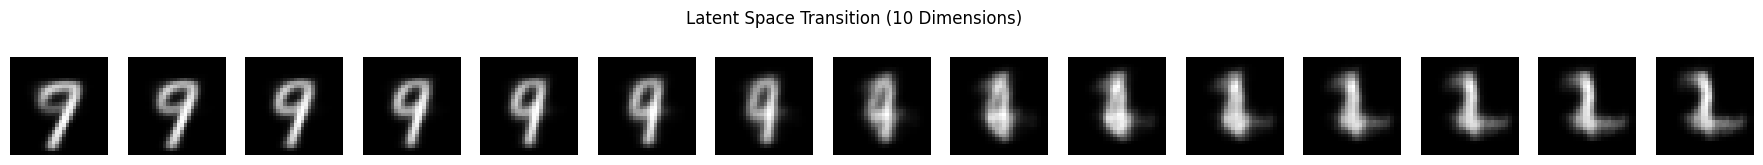

In [79]:
from matplotlib import pyplot as plt
import numpy as np

# --- 1. Configuration ---
EPOCHS = 60
LATENT_DIM = 10

# --- 2. Training Loop ---
def train(epochs):
    print("Starting training...")
    for epoch in range(epochs):
        # Progress bar for each epoch
        for image_batch in tqdm(dataset, desc=f"Epoch {epoch+1}/{epochs}"):
            train_loop(image_batch)

    print("Training Complete!")

# Execute the training
train(EPOCHS)

# --- 3. Latent Space Transition (Morphing) ---
def plot_transition(decoder_model, steps=12):
    """
    Interpolates between two random points in the latent space
    to show one digit smoothly morphing into another.
    """
    # Pick two random "anchor" points in the 10D latent space
    start_vec = tf.random.normal([1, LATENT_DIM])
    end_vec = tf.random.normal([1, LATENT_DIM])

    # Create a linear path (interpolation) between them
    ratios = np.linspace(0, 1, num=steps)
    vectors = [(1 - r) * start_vec + r * end_vec for r in ratios]

    # Stack into a single batch and decode
    vectors = tf.cast(tf.concat(vectors, axis=0), tf.float32)
    images = decoder_model(vectors, training=False)

    # Plot the "morphing" sequence in a single horizontal row
    plt.figure(figsize=(steps * 1.5, 2))
    for i in range(steps):
        plt.subplot(1, steps, i + 1)
        # Display grayscale image
        plt.imshow(images[i, :, :, 0], cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Latent Space Transition (10 Dimensions)")
    plt.show()

# --- 4. Run the Transition ---
# You can run this line multiple times to see different morphs!
plot_transition(Decoder, steps=15)

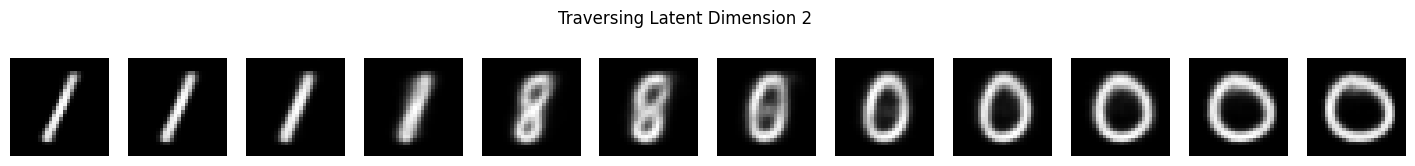

In [80]:
# Quick code to test one specific dimension (e.g., Dimension 0)
def traverse_dimension(decoder_model, dim_index=0, steps=12):
    val_range = np.linspace(-3, 3, num=steps)
    vectors = np.zeros((steps, 10))
    vectors[:, dim_index] = val_range # Only change one dimension

    images = decoder_model(tf.cast(vectors, tf.float32), training=False)

    plt.figure(figsize=(steps * 1.5, 2))
    for i in range(steps):
        plt.subplot(1, steps, i + 1)
        plt.imshow(images[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Traversing Latent Dimension {dim_index}")
    plt.show()

traverse_dimension(Decoder, dim_index=2) # Try changing the index from 0-9